In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os

print(os.listdir())

['02_data_cleaning.ipynb', '03_database_creation.ipynb', '04_EDA_Analysis.ipynb', '05_Performance_Analytics.ipynb', 'Advanced_Analytics.ipynb', 'data_loading.ipynb']


In [3]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

In [4]:
import pandas as pd

fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")
nav_history = pd.read_csv("../data/processed/02_nav_history_clean.csv")
investor_txn = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

print(fund_master.shape)
print(nav_history.shape)
print(investor_txn.shape)

(40, 15)
(46000, 3)
(32778, 13)


In [5]:
print("Fund Master Columns")
print(fund_master.columns.tolist())

print("\nNAV History Columns")
print(nav_history.columns.tolist())

print("\nInvestor Transaction Columns")
print(investor_txn.columns.tolist())

Fund Master Columns
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

NAV History Columns
['amfi_code', 'date', 'nav']

Investor Transaction Columns
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [6]:
import pandas as pd
import numpy as np

nav_history['date'] = pd.to_datetime(nav_history['date'])

nav_history = nav_history.sort_values(['amfi_code', 'date'])

nav_history['daily_return'] = (
    nav_history.groupby('amfi_code')['nav']
    .pct_change()
)

nav_history.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [7]:
var_results = []

for fund in nav_history['amfi_code'].unique():

    returns = nav_history.loc[
        nav_history['amfi_code'] == fund,
        'daily_return'
    ].dropna()

    if len(returns) > 30:

        var95 = np.percentile(returns, 5)

        cvar95 = returns[returns <= var95].mean()

        var_results.append([
            fund,
            var95,
            cvar95
        ])

var_cvar_report = pd.DataFrame(
    var_results,
    columns=['amfi_code', 'VaR_95', 'CVaR_95']
)

var_cvar_report.to_csv(
    '../reports/var_cvar_report.csv',
    index=False
)

var_cvar_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [8]:
import matplotlib.pyplot as plt
import numpy as np

sharpe_frames = []

for fund in nav_history['amfi_code'].unique():

    df = nav_history[
        nav_history['amfi_code'] == fund
    ].copy()

    df['rolling_sharpe'] = (
        df['daily_return'].rolling(90).mean()
        /
        df['daily_return'].rolling(90).std()
    ) * np.sqrt(252)

    sharpe_frames.append(df)

rolling_sharpe_df = pd.concat(sharpe_frames)

rolling_sharpe_df.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
5750,100016,2022-01-03,520.4608,NaN,NaN
5751,100016,2022-01-04,515.0971,-0.010306,NaN
5752,100016,2022-01-05,521.7239,0.012865,NaN
5753,100016,2022-01-06,515.7880,-0.011377,NaN
5754,100016,2022-01-07,515.1639,-0.001210,NaN


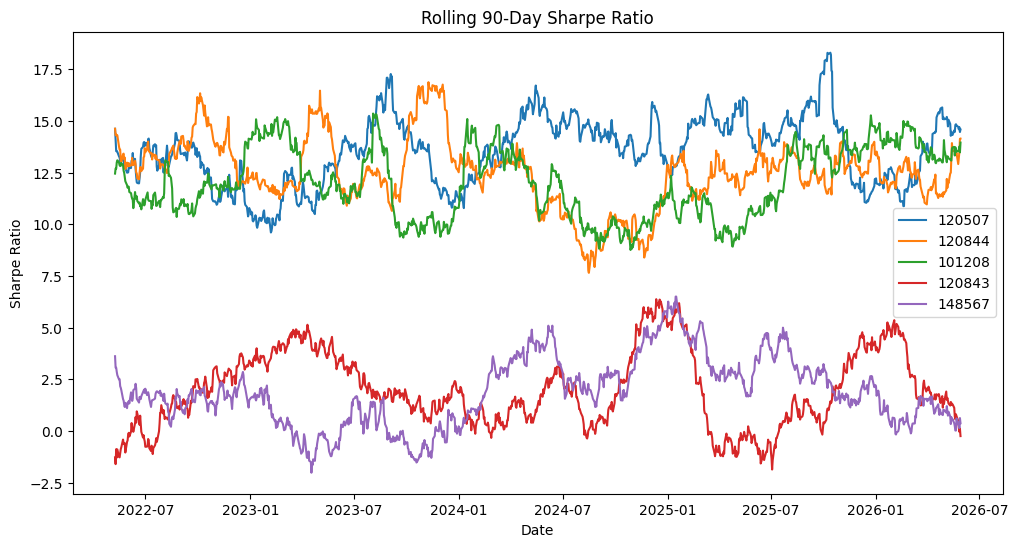

In [9]:
top5_funds = (
    rolling_sharpe_df.groupby('amfi_code')
    ['rolling_sharpe']
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

plt.figure(figsize=(12,6))

for fund in top5_funds:

    temp = rolling_sharpe_df[
        rolling_sharpe_df['amfi_code'] == fund
    ]

    plt.plot(
        temp['date'],
        temp['rolling_sharpe'],
        label=str(fund)
    )

plt.title('Rolling 90-Day Sharpe Ratio')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend()

plt.savefig(
    '../reports/rolling_sharpe_chart.png',
    bbox_inches='tight'
)

plt.show()

In [10]:
investor_txn['transaction_date'] = pd.to_datetime(
    investor_txn['transaction_date']
)

investor_txn['first_year'] = (
    investor_txn.groupby('investor_id')
    ['transaction_date']
    .transform('min')
    .dt.year
)

cohort_summary = (
    investor_txn.groupby('first_year')
    .agg(
        avg_sip_amount=('amount_inr','mean'),
        total_invested=('amount_inr','sum')
    )
    .reset_index()
)

cohort_summary.head()

,first_year,avg_sip_amount,total_invested
0,2024,107422.541832,3491125187
1,2025,109158.577061,30455243


In [11]:
cohort_summary.head()

,first_year,avg_sip_amount,total_invested
0,2024,107422.541832,3491125187
1,2025,109158.577061,30455243


In [12]:
sip_txn = investor_txn[
    investor_txn['transaction_type'] == 'SIP'
].copy()

sip_txn = sip_txn.sort_values(
    ['investor_id', 'transaction_date']
)

sip_txn['gap_days'] = (
    sip_txn.groupby('investor_id')
    ['transaction_date']
    .diff()
    .dt.days
)

sip_summary = (
    sip_txn.groupby('investor_id')
    .agg(
        sip_count=('transaction_date', 'count'),
        avg_gap_days=('gap_days', 'mean')
    )
    .reset_index()
)

sip_summary = sip_summary[
    sip_summary['sip_count'] >= 6
]

sip_summary['status'] = np.where(
    sip_summary['avg_gap_days'] > 35,
    'At-Risk',
    'Active'
)

sip_summary.head()

,investor_id,sip_count,avg_gap_days,status
3,INV000004,6,85.400000,At-Risk
7,INV000008,6,70.400000,At-Risk
9,INV000010,6,64.800000,At-Risk
10,INV000011,7,40.166667,At-Risk
11,INV000012,8,57.000000,At-Risk


In [13]:
sip_summary['status'].value_counts()

status
At-Risk    1332
Active       30
Name: count, dtype: int64

In [14]:
import pandas as pd

holdings = pd.read_csv("data/raw/09_portfolio_holdings.csv")

print(holdings.columns)
print(holdings.head())

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/09_portfolio_holdings.csv'

In [15]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if "portfolio" in file.lower():
            print(os.path.join(root, file))

In [16]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        print(os.path.join(root, file))

.\02_data_cleaning.ipynb
.\03_database_creation.ipynb
.\04_EDA_Analysis.ipynb
.\05_Performance_Analytics.ipynb
.\Advanced_Analytics.ipynb
.\data_loading.ipynb
.\recommender.py


In [17]:
import os
print(os.getcwd())

c:\Users\Aishmitha\OneDrive\Documents\mutual_fund_capstone\notebooks


In [18]:
import os

for root, dirs, files in os.walk("../data"):
    for file in files:
        if "portfolio" in file.lower():
            print(os.path.join(root, file))

../data\processed\09_portfolio_holdings_clean.csv
../data\raw\09_portfolio_holdings.csv


In [19]:
import pandas as pd

portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

print(portfolio.head())
print(portfolio.columns)

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


In [20]:
import pandas as pd

portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

# HHI = Sum of squared sector weights
hhi_df = portfolio.groupby("amfi_code").apply(
    lambda x: (x["weight_pct"] / 100).pow(2).sum()
).reset_index()

hhi_df.columns = ["amfi_code", "HHI"]

# Sort highest concentration first
hhi_df = hhi_df.sort_values("HHI", ascending=False)

print("Top 10 Most Concentrated Funds")
print(hhi_df.head(10))

Top 10 Most Concentrated Funds
    amfi_code       HHI
11     119092  0.206448
3      101207  0.200700
18     119599  0.174751
4      102885  0.174709
7      118632  0.168298
29     148568  0.167930
21     120505  0.157570
22     120506  0.153794
27     125498  0.152414
23     120841  0.149680


In [21]:
hhi_df.to_csv("../reports/sector_hhi_report.csv", index=False)

print("sector_hhi_report.csv saved successfully!")

sector_hhi_report.csv saved successfully!


In [22]:
var_cvar_df.to_csv("../reports/var_cvar_report.csv", index=False)

print("var_cvar_report.csv saved successfully!")

NameError: name 'var_cvar_df' is not defined

In [23]:
print(locals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'pd', 'np', 'plt', '_i2', 'os', '_i3', 'root', 'dirs', 'files', 'file', '_i4', 'fund_master', 'nav_history', 'investor_txn', '_i5', '_i6', '_6', '_i7', 'var_results', 'fund', 'returns', 'var95', 'cvar95', 'var_cvar_report', '_7', '_i8', 'sharpe_frames', 'df', 'rolling_sharpe_df', '_8', '_i9', 'top5_funds', 'temp', '_i10', 'cohort_summary', '_10', '_i11', '_11', '_i12', 'sip_txn', 'sip_summary', '_12', '_i13', '_13', '_i14', '_i15', '_i16', '_i17', '_i18', '_i19', 'portfolio', '_i20', 'hhi_df', '_i21', '_i22', '_i23'])


In [24]:
var_cvar_report.to_csv("../reports/var_cvar_report.csv", index=False)

print("var_cvar_report.csv saved successfully!")

var_cvar_report.csv saved successfully!
